# Customer Segmentation

## Introduction

In this project, we will use **KMeans** to segment the credit card company's customers into different groups, which will help to apply different business strategies for each type of customer.

Here is the data dictionary:

- customer_id: unique identifier for each customer.
- 
age: customer age in years
- gender: customer gender (M or F).
- dependent_count: number of dependents of each customer.
- education_level: level of education ("High School", "Graduate", etc.).
- marital_status: marital status ("Single", "Married", etc.).
- estimated_income: the estimated income for the customer projected by the data science team.
- months_on_book: time as a customer in months.
- total_relationship_count: number of times the customer contacted the company.
- months_inactive_12_mon: number of months the customer did not use the credit card in the last 12 months.
- credit_limit: customer's credit limit.
- total_trans_amount: the overall amount of money spent on the card by the customer.
- total_trans_count: the overall number of times the customer used the card.
- avg_utilization_ratio: daily average utilization ratiozation ratio.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



In [2]:
%matplotlib inline

In [3]:
df=pd.read_csv('C:/Users/Public/Documents/yang/Data Science Project/data/customer_segmentation.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10127 non-null  int64  
 1   age                       10127 non-null  int64  
 2   gender                    10127 non-null  object 
 3   dependent_count           10127 non-null  int64  
 4   education_level           10127 non-null  object 
 5   marital_status            10127 non-null  object 
 6   estimated_income          10127 non-null  int64  
 7   months_on_book            10127 non-null  int64  
 8   total_relationship_count  10127 non-null  int64  
 9   months_inactive_12_mon    10127 non-null  int64  
 10  credit_limit              10127 non-null  float64
 11  total_trans_amount        10127 non-null  int64  
 12  total_trans_count         10127 non-null  int64  
 13  avg_utilization_ratio     10127 non-null  float64
dtypes: flo

In [5]:
df.head()

,customer_id,age,gender,dependent_count,education_level,marital_status,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio
0,768805383,45,M,3,High School,Married,69000,39,5,1,12691.0,1144,42,0.061
1,818770008,49,F,5,Graduate,Single,24000,44,6,1,8256.0,1291,33,0.105
2,713982108,51,M,3,Graduate,Married,93000,36,4,1,3418.0,1887,20,0.000
3,769911858,40,F,4,High School,Unknown,37000,34,3,4,3313.0,1171,20,0.760
4,709106358,40,M,3,Uneducated,Married,65000,21,5,1,4716.0,816,28,0.000


- There is no missing value in the dataset.
- We will perform EDA on the dataset first

## EDA : Categorical Data and Numerical Data
- We will perform count plot on categorical data and histogram on numerical data.

In [6]:
#select the categorical columns
cat_cols=list(df.select_dtypes(include=['object']).columns)

In [7]:
cat_cols

['gender', 'education_level', 'marital_status']

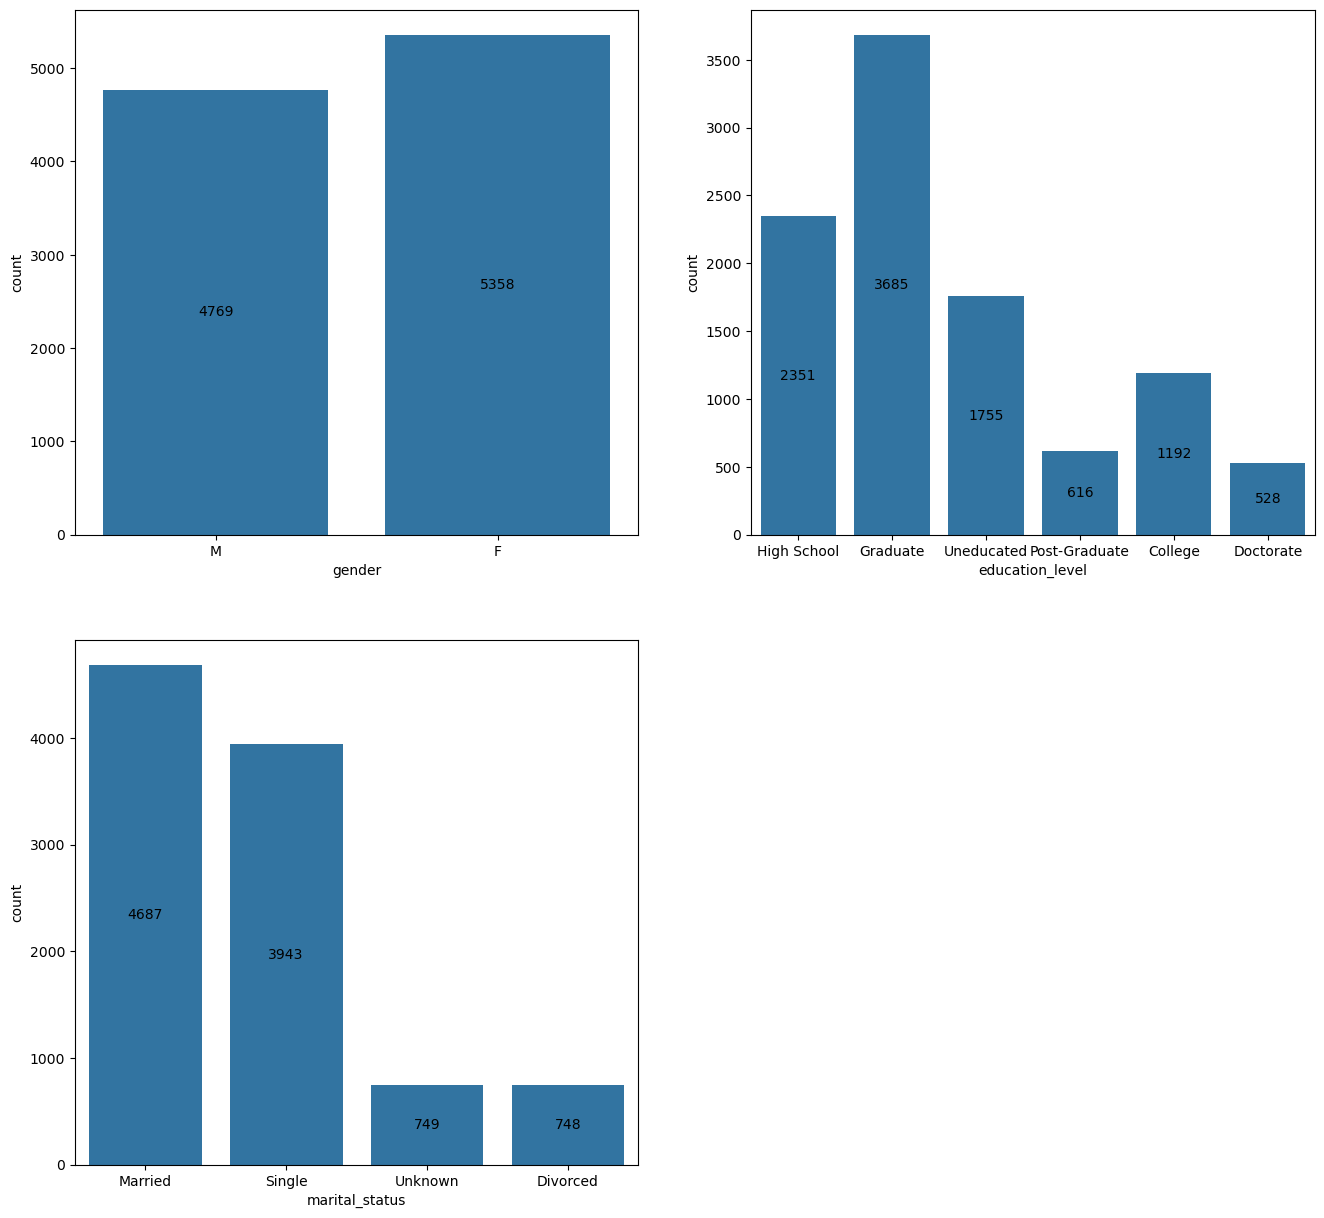

In [8]:
fig=plt.figure(figsize=(16,15))
for index,col in enumerate(cat_cols):
    ax=plt.subplot(2,2,index+1)
    sns.countplot(x=df[col],ax=ax)
    #add data labels
    for container in ax.containers:
        ax.bar_label(container,label_type='center')

Here is a summary of categorical data:
- There are more female customers than males
- customers with 'Graduate' degrees consist of the largest cohort
- most customers are 'married'

In [9]:
#select numerical columns
num_cols=list(df.select_dtypes(include=['int64','float64']).columns)
num_cols.remove('customer_id')
              

In [10]:
num_cols

['age',
 'dependent_count',
 'estimated_income',
 'months_on_book',
 'total_relationship_count',
 'months_inactive_12_mon',
 'credit_limit',
 'total_trans_amount',
 'total_trans_count',
 'avg_utilization_ratio']

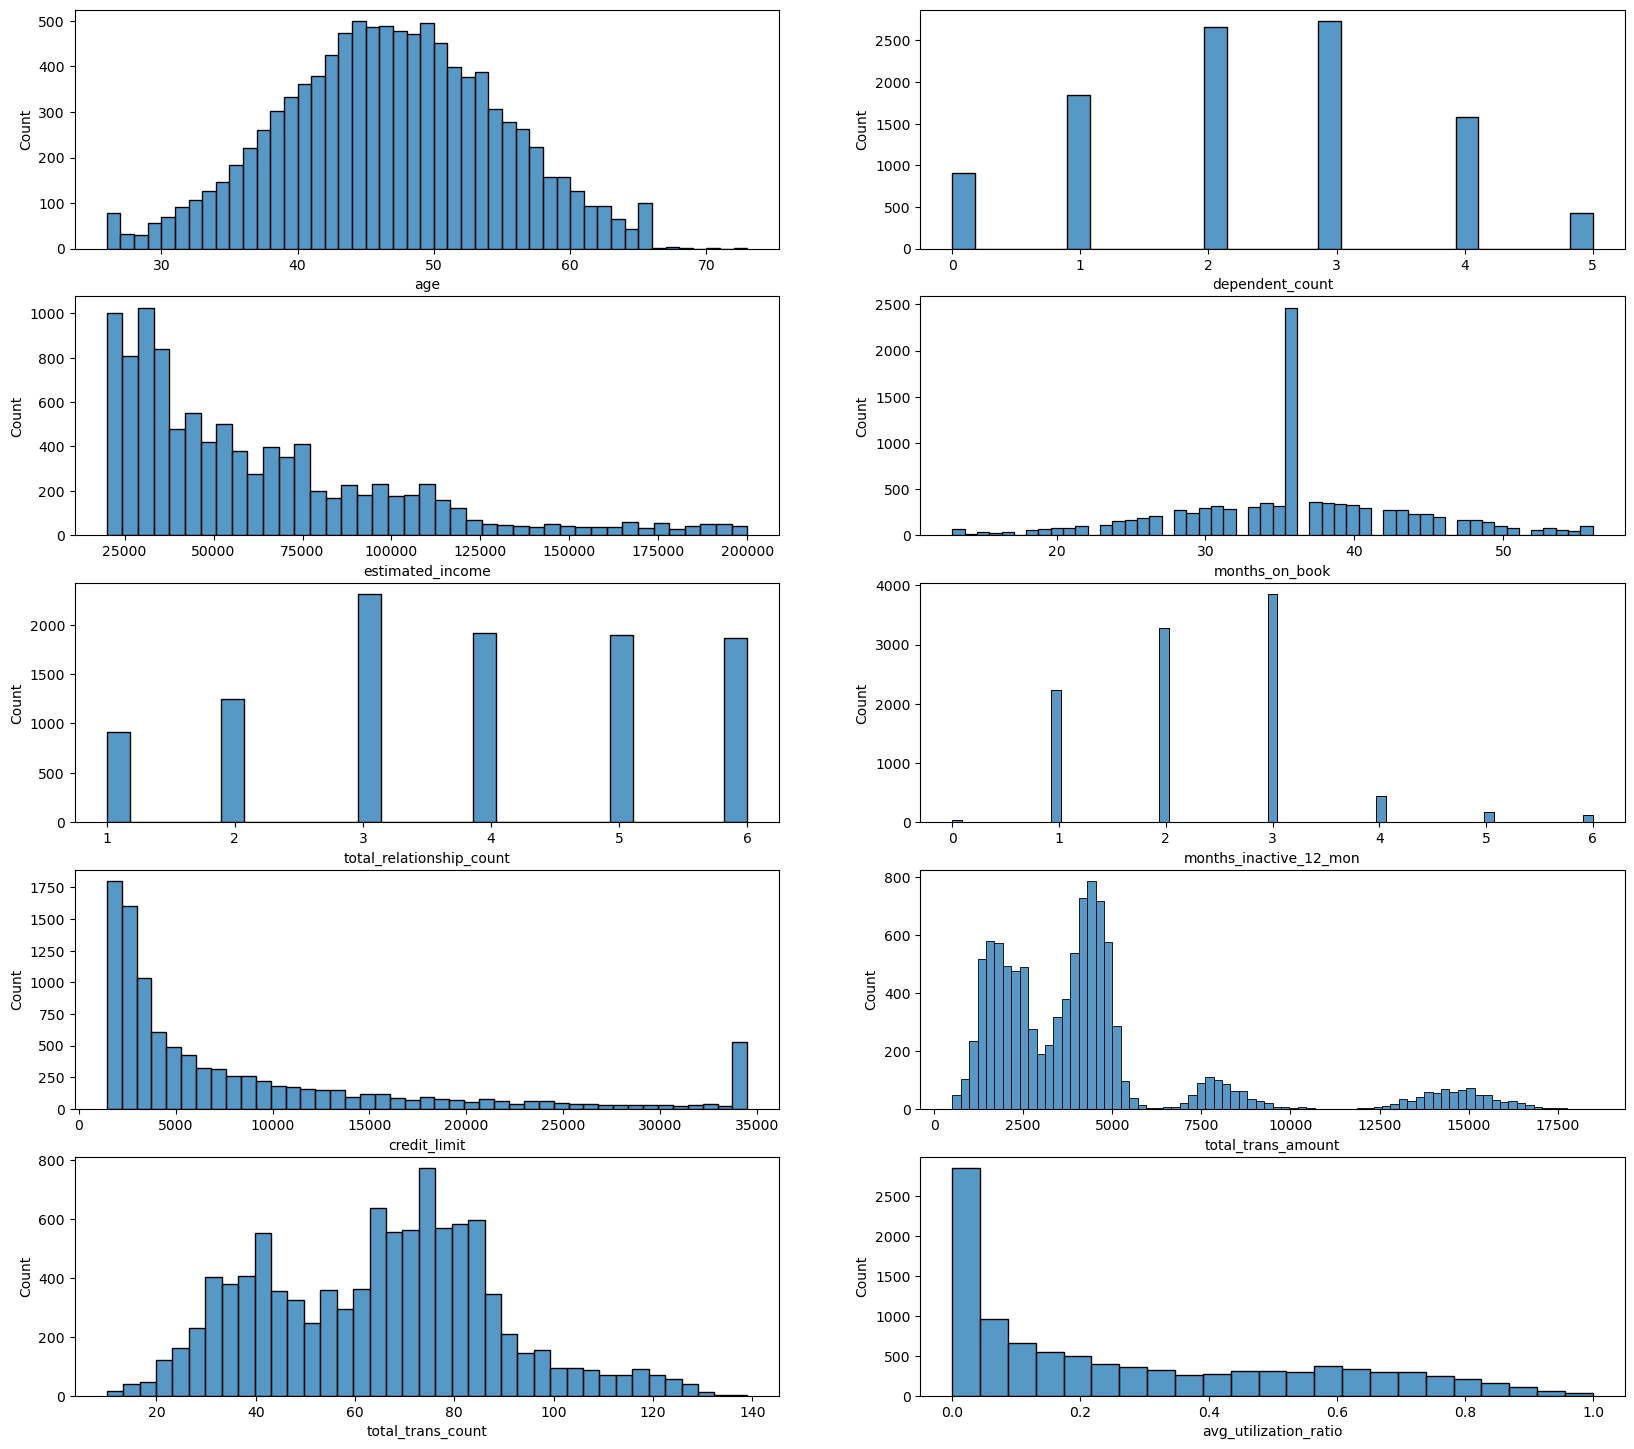

In [11]:
fig=plt.figure(figsize=(20,18))
for idex, col in enumerate(num_cols):
    ax=plt.subplot(5,2,idex+1)
    sns.histplot(x=df[col],ax=ax)

In [12]:
# explore the skewness of the numerical data
for col in num_cols:
    skewness=df[col].skew()
    print(f"{col}'s skewness is {skewness}")

age's skewness is -0.033605016317173456
dependent_count's skewness is -0.020825535616339912
estimated_income's skewness is 1.3615188240734424
months_on_book's skewness is -0.10656535989402989
total_relationship_count's skewness is -0.16245241498173682
months_inactive_12_mon's skewness is 0.6330611289713137
credit_limit's skewness is 1.666725807993647
total_trans_amount's skewness is 2.0410034025756936
total_trans_count's skewness is 0.15367306849872275
avg_utilization_ratio's skewness is 0.7180079967731994


The columns of 'estimated_income', 'credit_limit', and 'total_trans_amount' are  right-skewed

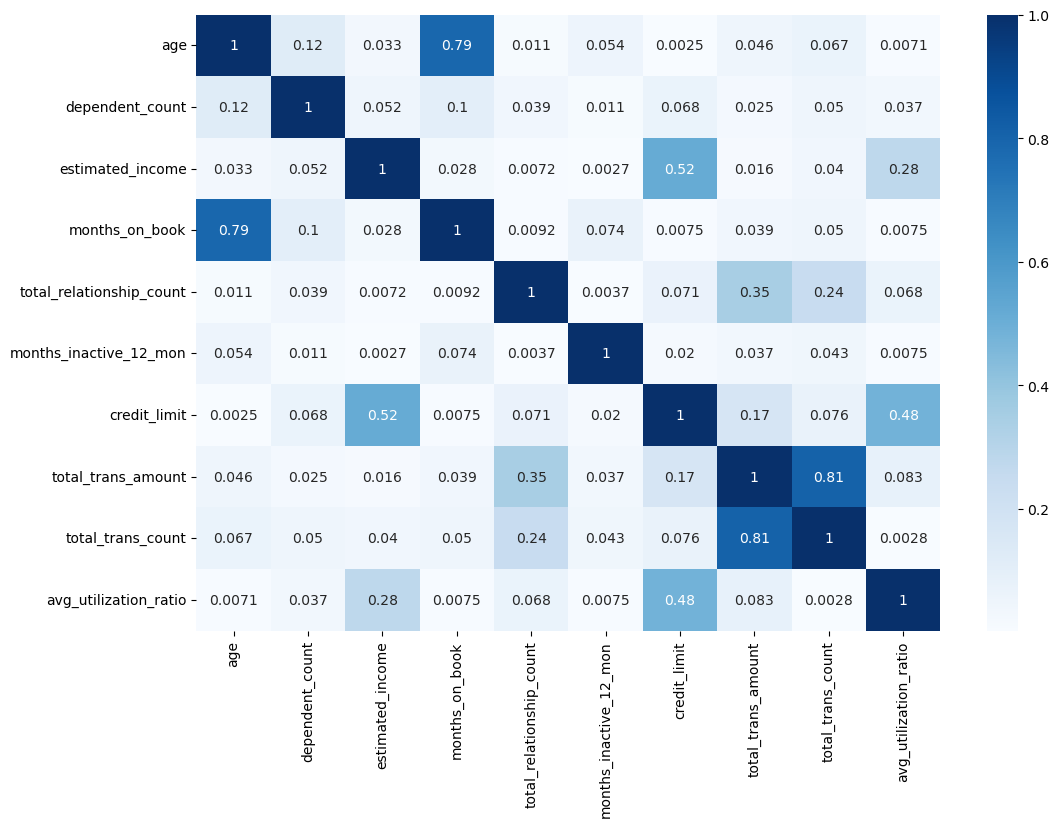

In [13]:
#let's explore the autocorrelation among numerical data
corl=abs(df[num_cols].corr())
plt.figure(figsize=(12,8))
sns.heatmap(corl,annot=True,cmap='Blues')
plt.show()

From the heatmap, we can see several variables are autocorrelated(the correlations are intuitive and self-explainatory):
1. 'age' and 'months_on_book'
2. 'credit_limit' and 'estimated_income'
3. 'total_trans_count' and' total_trans_amount'
4. 'credit_limit' and 'avg_utilization_ratio'

## Feature Engineering
There are two major steps of feature engineering in this project:
1. Convert the categorical data
2. standardize the variables

Let's convert the categorical data first as follows:
- 'gender' column will convert to M:1 AND F:0
- 'education_level' column will convert to :'Uneducated':0,'High School':1, 'College':2,'Graduate':3 , 'Post-Graduate':4,
       'Doctorate':5

In [14]:
df_clean=df.copy()

In [15]:
df_clean['gender']=df_clean['gender'].apply(lambda x : 1 if x=='M' else 0)

In [16]:
df_clean['education_level']=df_clean['education_level'].map({'Uneducated':0,'High School':1, 'College':2,'Graduate':3 , 'Post-Graduate':4,
       'Doctorate':5})

In [17]:
df_clean.head()

,customer_id,age,gender,dependent_count,education_level,marital_status,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio
0,768805383,45,1,3,1,Married,69000,39,5,1,12691.0,1144,42,0.061
1,818770008,49,0,5,3,Single,24000,44,6,1,8256.0,1291,33,0.105
2,713982108,51,1,3,3,Married,93000,36,4,1,3418.0,1887,20,0.000
3,769911858,40,0,4,1,Unknown,37000,34,3,4,3313.0,1171,20,0.760
4,709106358,40,1,3,0,Married,65000,21,5,1,4716.0,816,28,0.000


In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10127 non-null  int64  
 1   age                       10127 non-null  int64  
 2   gender                    10127 non-null  int64  
 3   dependent_count           10127 non-null  int64  
 4   education_level           10127 non-null  int64  
 5   marital_status            10127 non-null  object 
 6   estimated_income          10127 non-null  int64  
 7   months_on_book            10127 non-null  int64  
 8   total_relationship_count  10127 non-null  int64  
 9   months_inactive_12_mon    10127 non-null  int64  
 10  credit_limit              10127 non-null  float64
 11  total_trans_amount        10127 non-null  int64  
 12  total_trans_count         10127 non-null  int64  
 13  avg_utilization_ratio     10127 non-null  float64
dtypes: flo

In [19]:
df_clean1=pd.get_dummies(df_clean,dtype='int64')

In [20]:
df_clean1.head()

,customer_id,age,gender,dependent_count,education_level,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Unknown
0,768805383,45,1,3,1,69000,39,5,1,12691.0,1144,42,0.061,0,1,0,0
1,818770008,49,0,5,3,24000,44,6,1,8256.0,1291,33,0.105,0,0,1,0
2,713982108,51,1,3,3,93000,36,4,1,3418.0,1887,20,0.000,0,1,0,0
3,769911858,40,0,4,1,37000,34,3,4,3313.0,1171,20,0.760,0,0,0,1
4,709106358,40,1,3,0,65000,21,5,1,4716.0,816,28,0.000,0,1,0,0


In [21]:
df_clean1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10127 non-null  int64  
 1   age                       10127 non-null  int64  
 2   gender                    10127 non-null  int64  
 3   dependent_count           10127 non-null  int64  
 4   education_level           10127 non-null  int64  
 5   estimated_income          10127 non-null  int64  
 6   months_on_book            10127 non-null  int64  
 7   total_relationship_count  10127 non-null  int64  
 8   months_inactive_12_mon    10127 non-null  int64  
 9   credit_limit              10127 non-null  float64
 10  total_trans_amount        10127 non-null  int64  
 11  total_trans_count         10127 non-null  int64  
 12  avg_utilization_ratio     10127 non-null  float64
 13  marital_status_Divorced   10127 non-null  int64  
 14  marita

We have different scaled variables, ranging from one digit to hundreds of thousands. For better segmentation performance, we need to scale all data to the same level by **'StandardScaler'**

In [22]:
df_clean1.drop('customer_id',axis=1, inplace=True) #drop the 'customer_id' column
scaler=StandardScaler()
scaler.fit(df_clean1) # fit the data
df_scaled=scaler.transform(df_clean1) #scaling the data

In [23]:
df_bd=pd.DataFrame(df_scaled,columns=[df_clean1.columns])

In [24]:
df_bd.head()


,age,gender,dependent_count,education_level,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Unknown
0,-0.165406,1.059956,0.503368,-0.752211,0.175810,0.384621,0.763943,-1.327136,0.446622,-0.959707,-0.973895,-0.775882,-0.282405,1.077338,-0.798507,-0.282609
1,0.333570,-0.943436,2.043199,0.662787,-0.967166,1.010715,1.407306,-1.327136,-0.041367,-0.916433,-1.357340,-0.616276,-0.282405,-0.928214,1.252337,-0.282609
2,0.583058,1.059956,0.503368,0.662787,0.785397,0.008965,0.120579,-1.327136,-0.573698,-0.740982,-1.911206,-0.997155,-0.282405,1.077338,-0.798507,-0.282609
3,-0.789126,-0.943436,1.273283,-0.752211,-0.636973,-0.241473,-0.522785,1.641478,-0.585251,-0.951758,-1.911206,1.759686,-0.282405,-0.928214,-0.798507,3.538459
4,-0.789126,1.059956,0.503368,-1.459710,0.074212,-1.869317,0.763943,-1.327136,-0.430877,-1.056263,-1.570365,-0.997155,-0.282405,1.077338,-0.798507,-0.282609


## Segmentation and Select the Number of Clusters(K)

We have the data ready for segmentation. We can perform the following analysis:
1. conduct a series of segmentations and create a list of inertia metric
2. plot the Elbow Curve of inertias and decide the best number of clusters(K)
3. use the selected K to perform segmentation and interpret the results

In [25]:
# Initiate a empty list to store inertias
inertias=list()

#try  the number of clusters ranging from 1 to 10
for k in range(1,11):
    model=KMeans(n_clusters=k)
    cluster=model.fit_predict(df_scaled)
    inertias.append(model.inertia_)
    



In [26]:
inertias

[162032.00000000012,
 144917.96517122665,
 133640.8747650964,
 126576.94666318165,
 111788.51743009673,
 103875.13629243856,
 105027.99419520277,
 95025.32882849342,
 92433.09597683453,
 91146.10335042013]

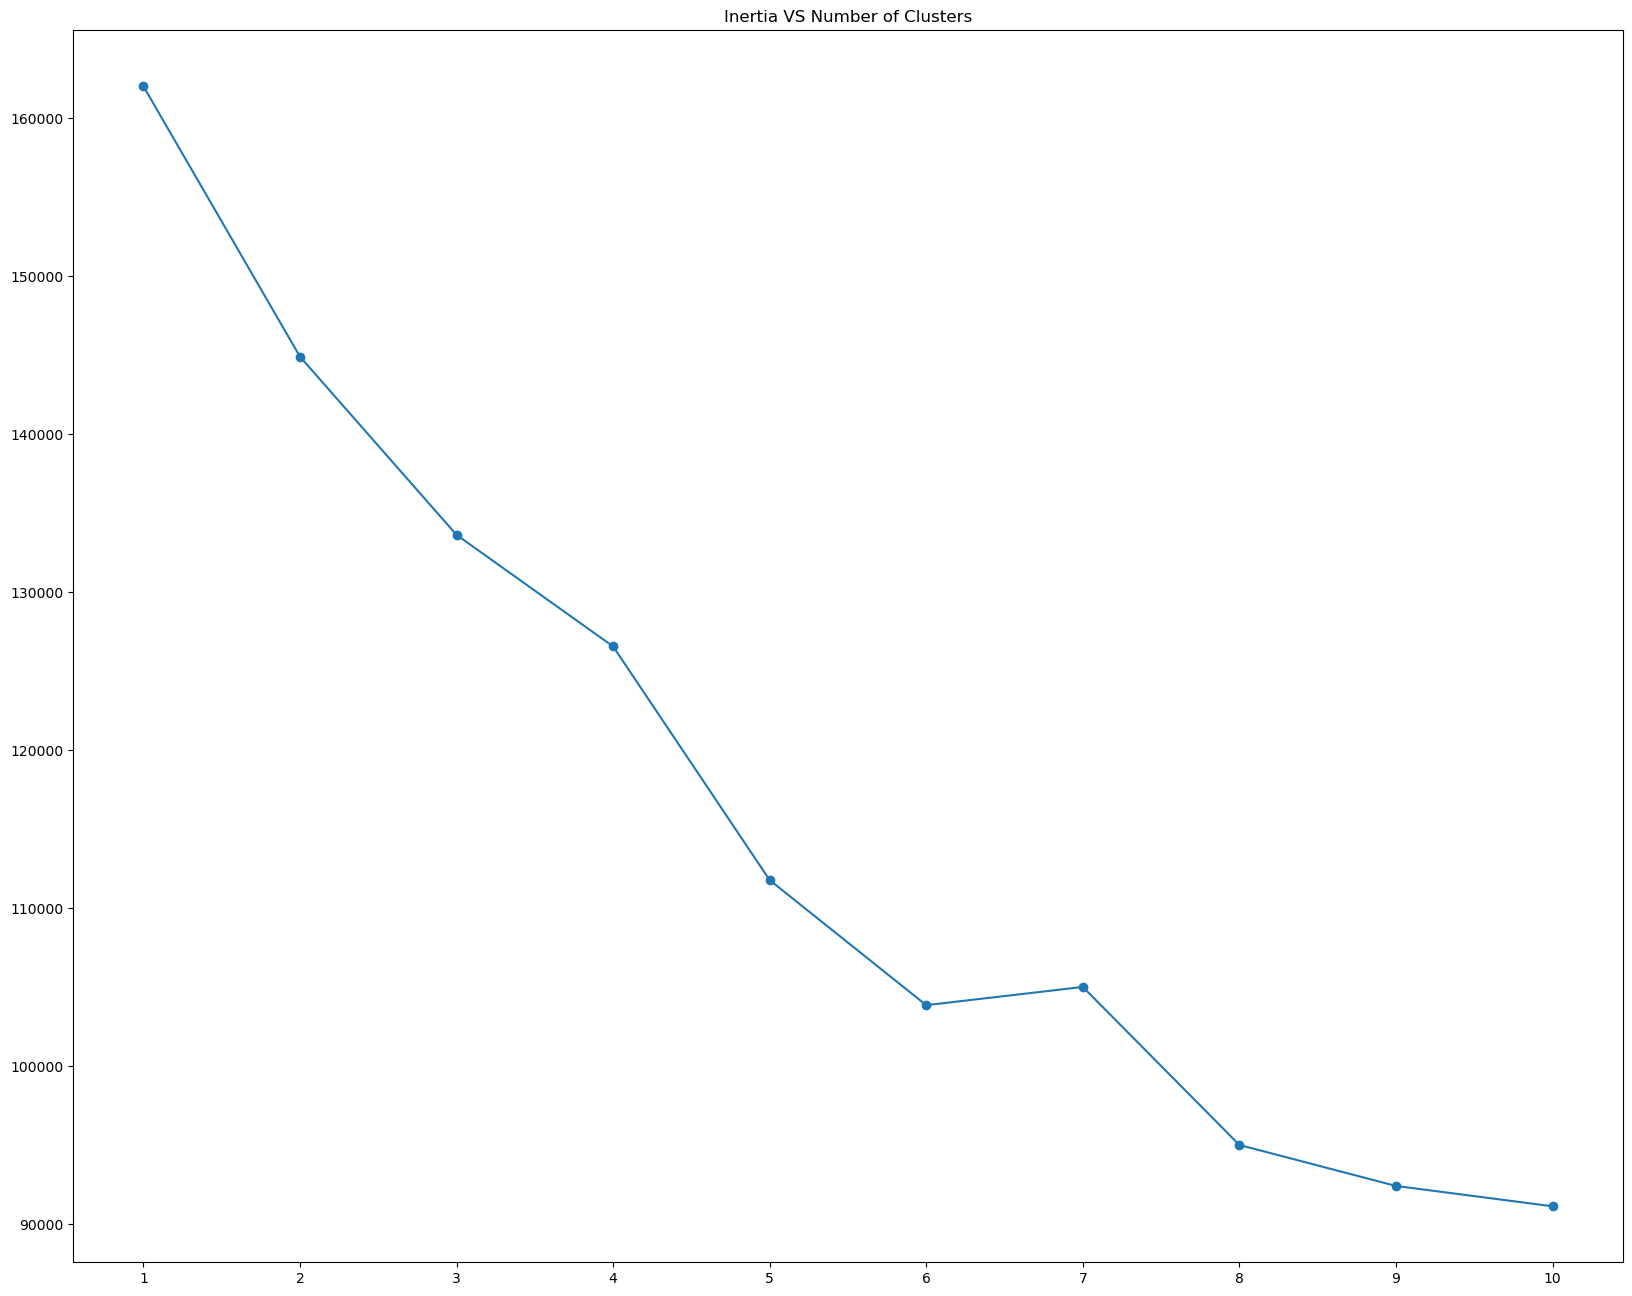

In [27]:
#plotting the Elbow Curve

plt.figure(figsize=(20,16))
plt.plot(range(1,11),inertias,marker='o')
plt.xticks(ticks=range(1,11),labels=range(1,11))
plt.title('Inertia VS Number of Clusters')
plt.show()

The rate of decreasing of inertia appears to slow down at 6 cluster. We will select 6 clusters for the final segmentation.

In [28]:
model=KMeans(n_clusters=6)
clusters=model.fit_predict(df_scaled)

In [29]:
clusters

array([0, 3, 0, ..., 4, 3, 4])

## Interpret Results

In [30]:
# assign the clusters back to the original data
df['clusters']=clusters+1  #clusters numbering staring at 0, therefore adding 1 to the actual clustering.

In [31]:
df['clusters'].value_counts()

clusters
4    2711
5    2535
1    1814
2    1409
3     923
6     735
Name: count, dtype: int64

First, we will analyze the numerical variables and investigate the characteristics in each cluster.

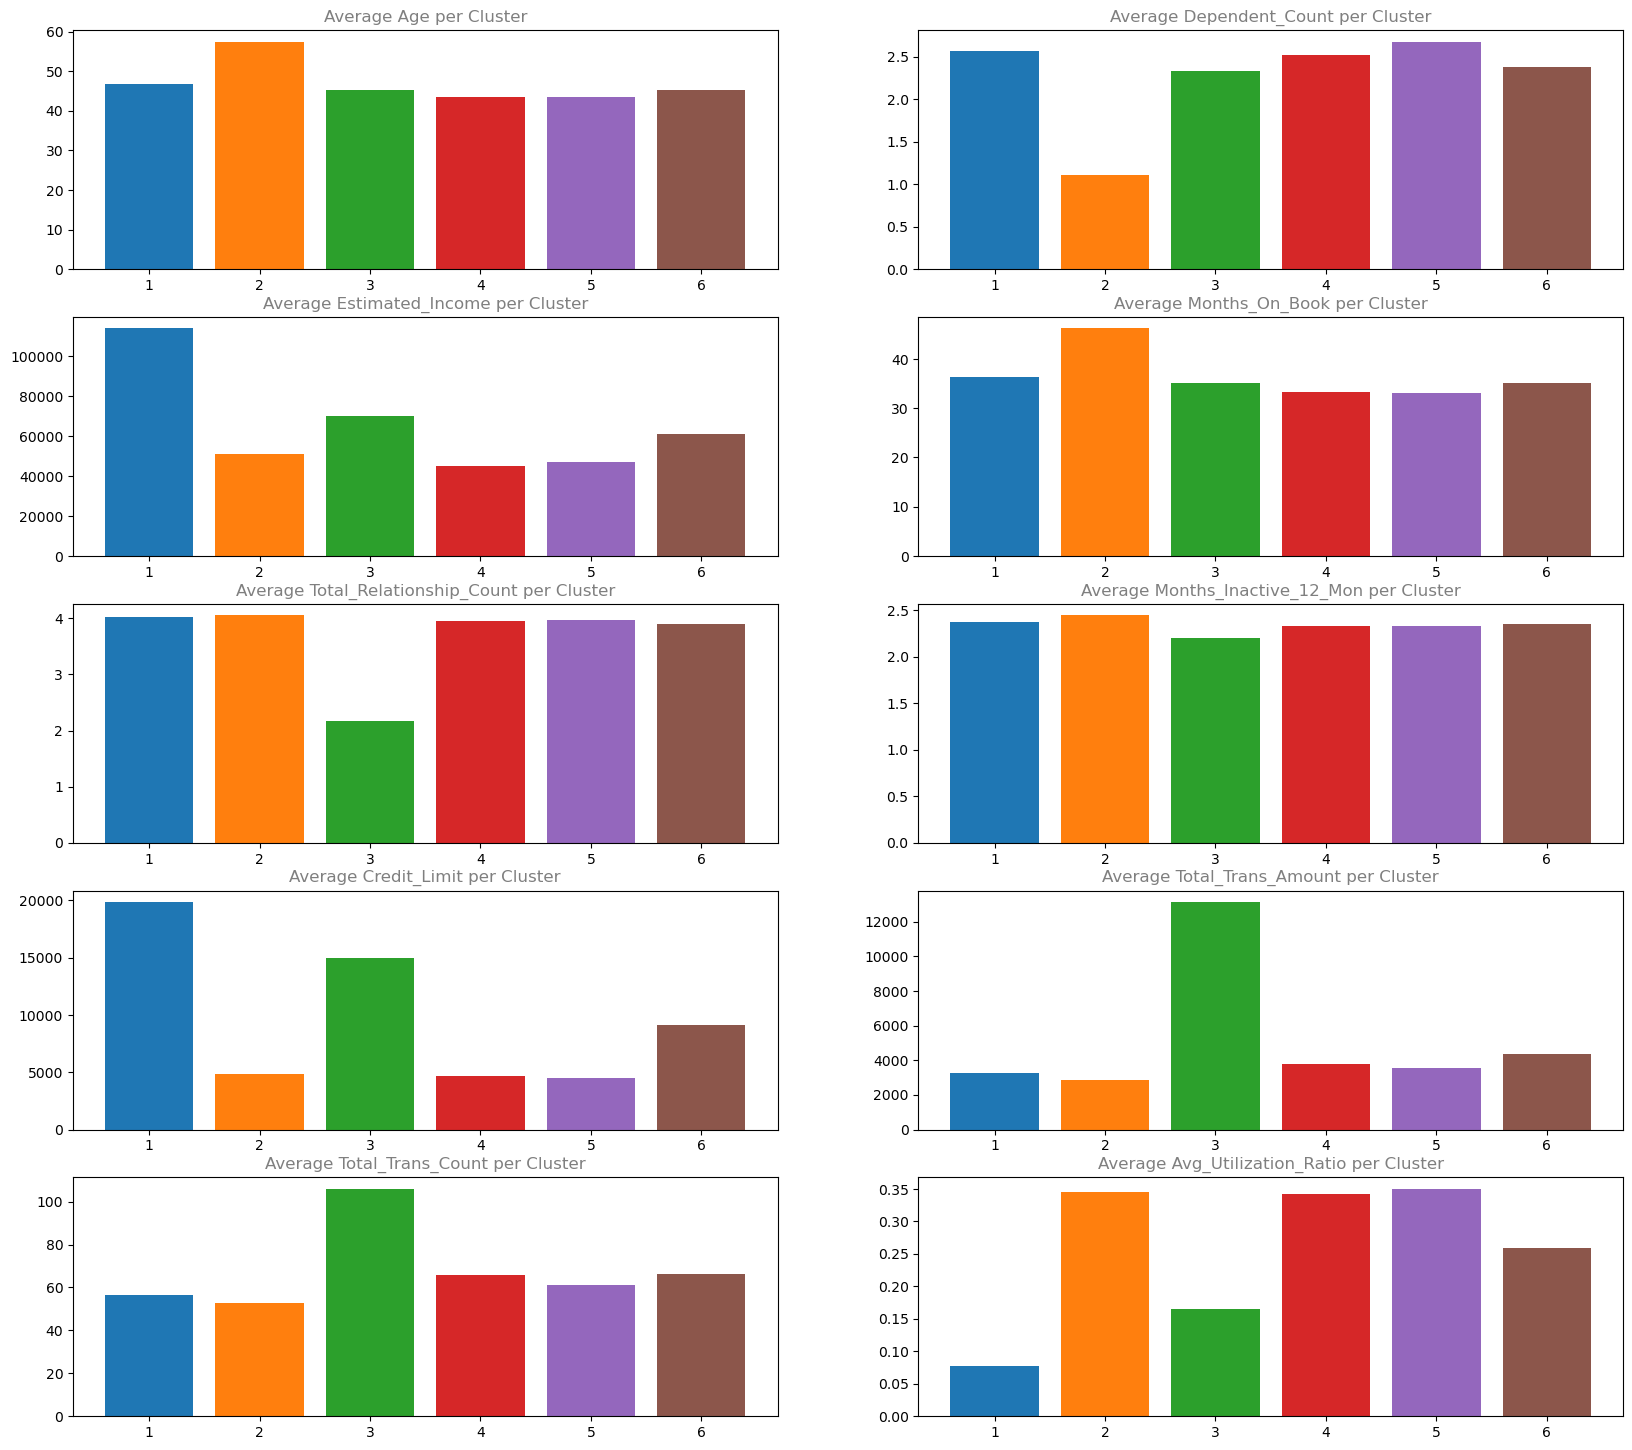

In [32]:
plt.figure(figsize=(20,18))
for idx,col in enumerate(num_cols):
    avg=df.groupby('clusters')[col].mean()
    ax=plt.subplot(5,2,idx+1)
    ax.bar(avg.index,avg,color=sns.color_palette('tab10'))
    ax.set_title(f'Average {col.title()} per Cluster', alpha=0.5)
plt.show()

We can draw some preliminary conclusions from the bar chart.
- Cluster 2 is older than other groups
- Cluster 1 has the high average income and credit limit,but have the low utilization ratio and total transcation amount
- Cluster 2,4,and 5 have the low average income and credit limit, but have the highest utilization ratio
- Cluster 3 has the highest total transcation amount and count, but have the middle levels of income and credit limit

It's a good start. To observe the patterns more clearly, let's use scatter plots to plot the following variable pairs:
1. 'Estimated_income' and 'avg_utilization_ratio'
2. 'Credit_limit' and 'avg_utilization_ratio'
3. 'Total_Trans_Amount' and 'avg_utilization_ratio'
4. 'estimated_income' and 'Total_Trans_Amount'


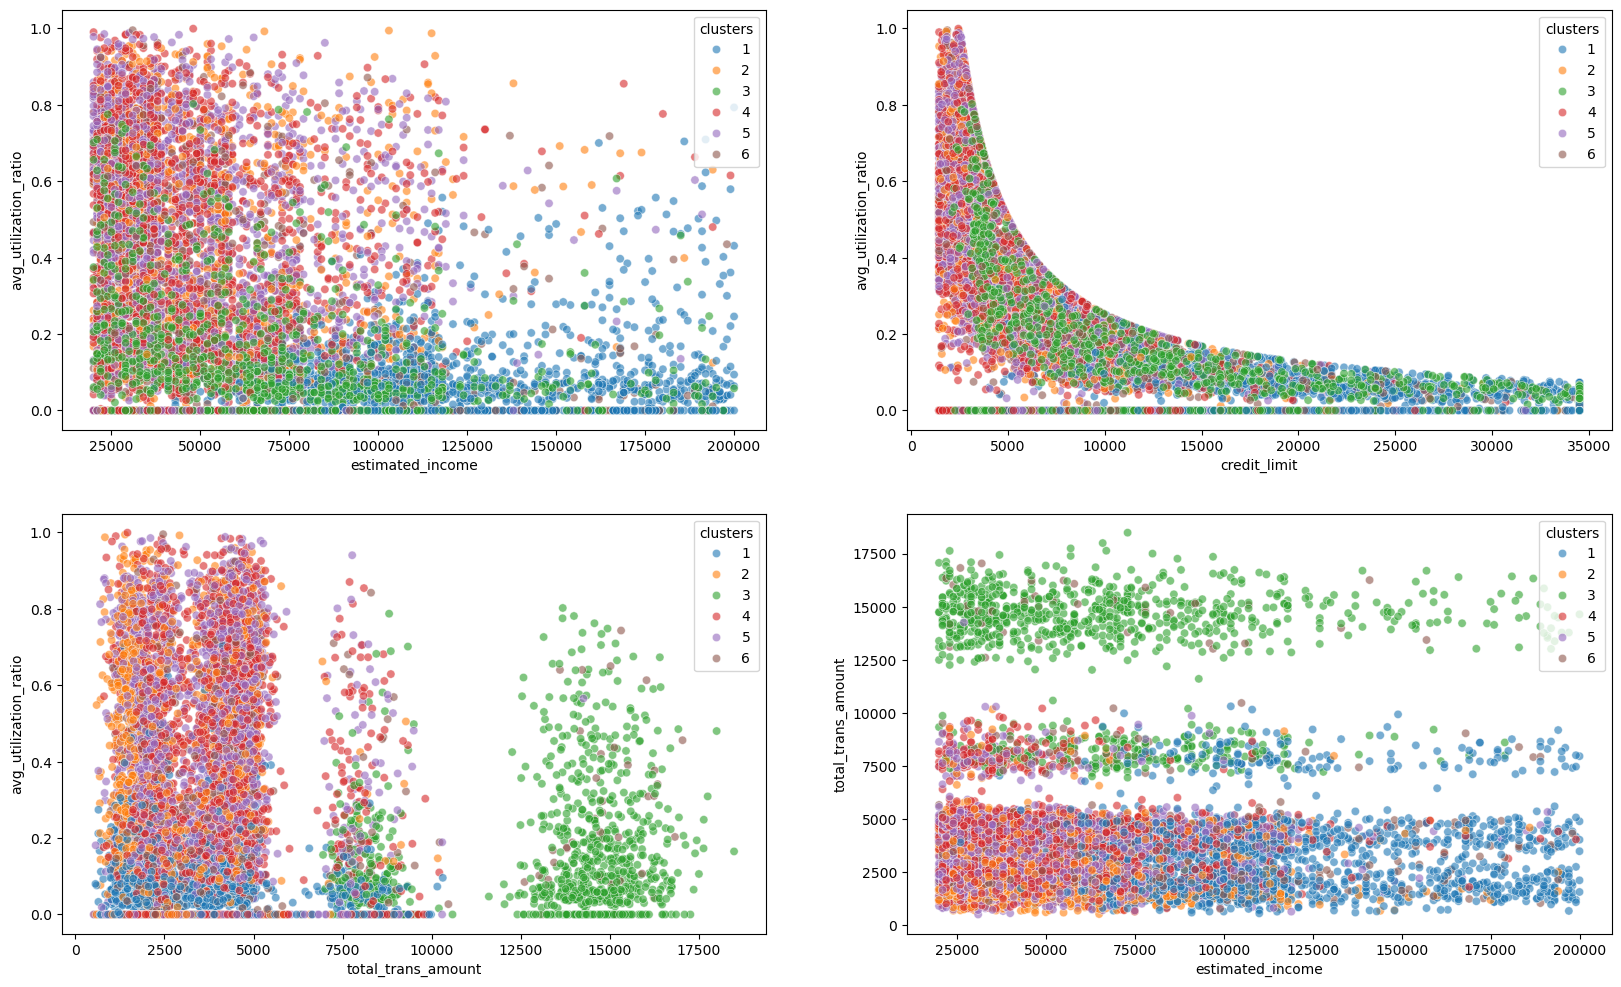

In [33]:
fig,ax=plt.subplots(2,2,figsize=(20,12))
sns.scatterplot(x='estimated_income', y='avg_utilization_ratio',hue='clusters',data=df,palette='tab10',alpha=0.6,ax=ax[0][0])
sns.scatterplot(x='credit_limit',y='avg_utilization_ratio',hue='clusters',data=df, palette='tab10', alpha=0.6,ax=ax[0][1])
sns.scatterplot(x='total_trans_amount',y='avg_utilization_ratio',hue='clusters',data=df, palette='tab10',alpha=0.6,ax=ax[1][0])
sns.scatterplot(x='estimated_income',y='total_trans_amount',hue='clusters',data=df, palette='tab10', alpha=0.6,ax=ax[1][1])

plt.show()

Let's plot the categorical variables grouped by clusters to further explore the characteristics of each cluster.

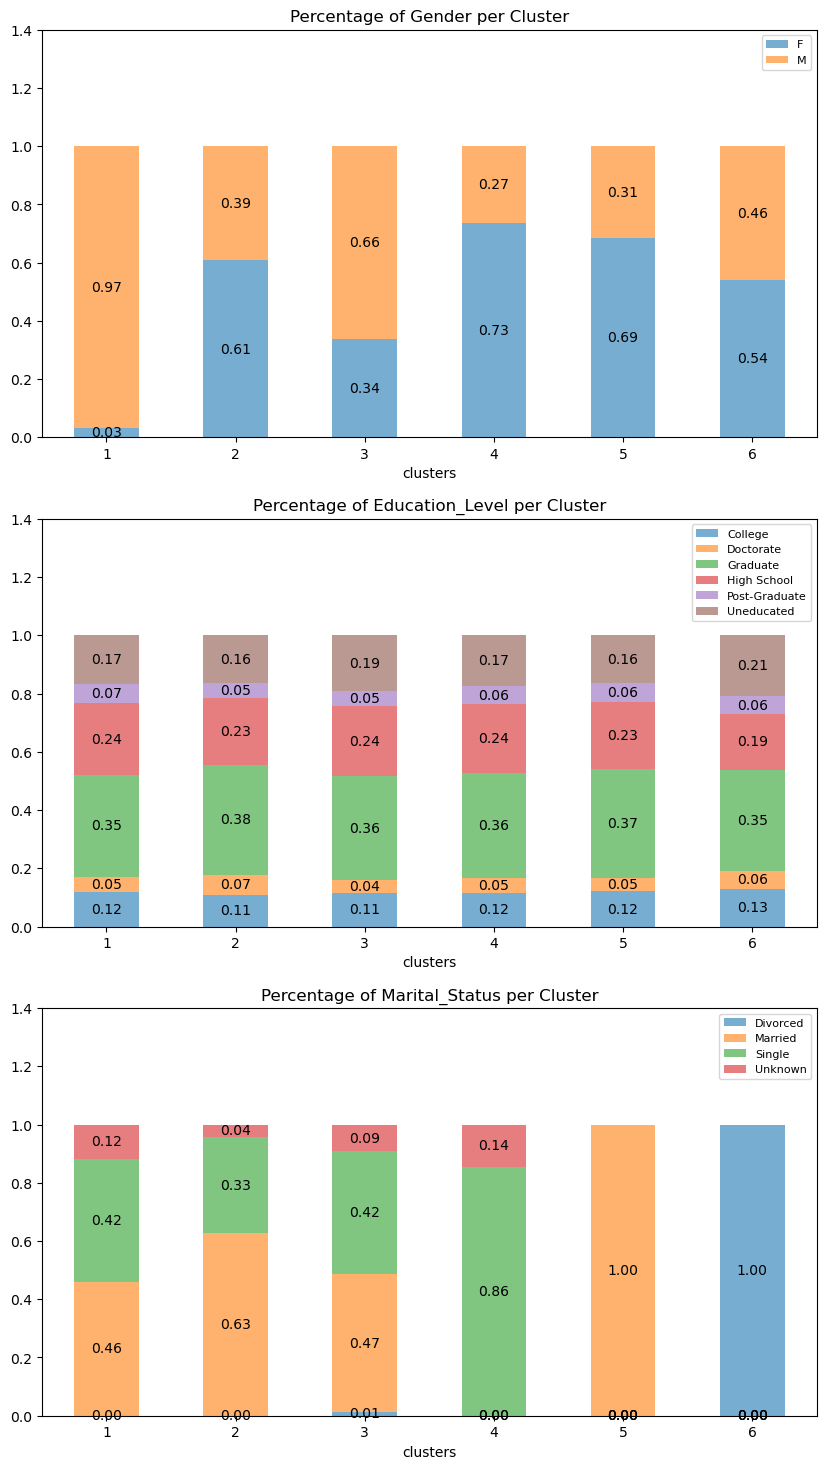

In [41]:
plt.figure(figsize=(10,18))
for idx, col in enumerate(cat_cols):
    plot_df=pd.crosstab(index=df['clusters'],columns=df[col],values=df[col],aggfunc='size',normalize='index')
    ax=plt.subplot(3,1,idx+1)
    plot_df.plot.bar(stacked=True,ax=ax, alpha=0.6)
    
    ax.set_title(f"Percentage of {col.title()} per Cluster")
    
    ax.set_ylim(0,1.4)
    ax.legend(fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(),rotation=360)
    #add data labels
    for c in ax.containers:
        ax.bar_label(c,fmt='%.2f',label_type='center')
    
    
plt.show()

Since Cluster 3 has the highest level of total transaction amount and count, let's investigate this group further to answer two questions:
1. Whether males or females spend more?
2. Are there any differences among different marital_status?

In [43]:
cluster_3=df[df['clusters']==3]

In [45]:
cluster_3_tamt=cluster_3.groupby('gender')['total_trans_amount'].mean()

In [47]:
cluster_3_tamt

gender
F    13718.782748
M    12861.329508
Name: total_trans_amount, dtype: float64

In [48]:
cluster_3_mar=cluster_3.groupby('marital_status')['total_trans_amount'].mean()

In [49]:
cluster_3_mar

marital_status
Divorced    15433.538462
Married     13336.680460
Single      13061.720513
Unknown     12273.258824
Name: total_trans_amount, dtype: float64

In [53]:
cluster_3_crst=pd.crosstab(index=cluster_3['gender'],columns=cluster_3['marital_status'],values=cluster_3['total_trans_amount'],aggfunc='mean')

In [54]:
cluster_3_crst

marital_status,Divorced,Married,Single,Unknown
gender,,,,
F,15670.250000,13971.354610,13584.564286,12839.214286
M,15328.333333,13032.295918,12768.928000,11995.245614


Here is a summary of the brief analysis on Cluster 3:
- Females tend to spend more than males
- Divorced custmers tend to spend more than others

## Conclusions

Among the clusters,there is no significant difference in education level.
However, we discover some distinctions for each cluster:

1. **Cluster 1** mainly consists of males(97%), evenly being divided between 'married' and 'single'. They have the highest income level and credit limit among all clusters, but spend very little in both average utilization ratio and total transaction amount.
2. **Cluster 2** has 60% of females and 40% of males, with a relatively older population among all the clusters.The majority of them are married(63%). They tend to have fewer children(dependents) than other groups. They have low income and credit limit, but have  a high average utilization ratio. According to the total transaction count and amount, they don't spend too much on credit cards.
3. **Cluster 3** has 66% of males and 34 of females,about half of 'married' and half of 'single'. They don't contact the company very often.They have a middle level of income, credit limit, and average utilization ratio. However, they tend to use credit cards on large purchases and have the highes level of total transaction amount among all groups.
4. **Cluster 4** mostly consists of single female. They don't have high income and credit limit. They tend to use credit cards very often on small purchases
5. **Cluster 5** only consists of married customers, with 69% of females and 31% of males. They tend to use credit card frequently on small purchases.
6. **Cluster 6** only consists of divorces customers. They don't stand out in any characteristics.
7. **Divorced Customers**, especially **Divorced females** spend most on credit cards